# Plot the salinity time series at a few locations in the delta for the three DCP pumping runs to show that the number 
# of sinks has little impact on south Delta salinity

In [1]:
# import numpy as np 
import sys
import numpy as np
import pandas as pd
import datetime as datetime    
import xarray as xr 
import matplotlib.pyplot as plt 
import matplotlib.dates as mdates 
import matplotlib as mpl
import re 
from scipy import signal #for filtering
import cmocean
import matplotlib.dates as mdates
print("Modules imported")

Modules imported


In [2]:
import re 
file="/global/scratch/users/jennaisrael/run_schism/run_test4sinks/station.in"
station_id =[]
with open(file) as f:
    f.readline()
    for station in range(int(f.readline())):
        line = f.readline()
        if '!' in line:
            station_id.append(line.split('!')[-1])
        else:
            station_id.append(None)
# print(station_id)

print(len(station_id))

stations = []
for sublist in station_id:
    match = re.search(r'"(.*?)"', sublist)
    if match:
        stations.append(match.group(1).strip())
    else :
        stations.append(sublist.replace("\n", "").strip())
print(len(set(stations)))


for i, station in enumerate(stations):
    print("%d == %s" % (i+1,station))

596
546
1 == San Joaquin at Antioch
2 == Mokelumne River at Benson's Ferry
3 == Cache Slough
4 == Cache Creek at Yolo
5 == Old River at Coney Island
6 == Clifton Court
7 == Discovery Bay at Indian Slough
8 == Doughty Cut above Grant Line Canal
9 == Sacramento River at Emmaton
10 == Sacramento River at Emmaton
11 == emm upper Emmaton
12 == emm lower Emmaton
13 == Farrar Park
14 == Grant Line Canal at Tracy Rd Bridge
15 == Green's Landing
16 == Harvey O Banks PP
17 == Holland Tract
18 == Harvey O Banks PP
19 == CCWD Old River near Discovery Bay
20 == CCWD Rock Slough PP
21 == Italian Slough Headwater near Byron
22 == Jersey Point
23 == Sacramento River at Mallard Island
24 == Sacramento River at Mallard Island
25 == Middle River at Howard Rd Bridge
26 == San Joaquin at Mossdale Bridge
27 == Middle River at Tracy Blvd
28 == Old River Barrier near DMC (Above)
29 == Old River below Dam
30 == Old River at Bacon Island
31 == Old River at Head
32 == Old River at Byron
33 == Prisoners Point
34 

In [3]:
file4='/global/scratch/users/jennaisrael/run_schism/run_test4sinks/outputs/staout_6'
file8='/global/scratch/users/jennaisrael/run_schism/run_test8sinks/outputs/staout_6'
file12='/global/scratch/users/jennaisrael/run_schism/run_test12sinks/outputs/staout_6'

In [4]:
#load the unfiltered data
columns = ['time']
stations_no = [str(i) for i in np.arange(1,597)]
columns = columns + stations_no

run13_r=pd.read_csv(file4, sep='\s+', names=columns,dtype=np.float32)
timedelta = [pd.Timedelta(i, unit = 's') for i in run13_r.time]
timestamp = [pd.to_datetime("08-14-2018 00:00:00") + i for i in timedelta]  
run13_r['time'] = timestamp
run13_r.set_index("time",inplace=True)
run14_r=pd.read_csv(file8, sep='\s+', names=columns,dtype=np.float32)
timedelta = [pd.Timedelta(i, unit = 's') for i in run14_r.time]
timestamp = [pd.to_datetime("08-14-2018 00:00:00") + i for i in timedelta] 
run14_r['time'] = timestamp
run14_r.set_index("time",inplace=True)
run15_r=pd.read_csv(file12, sep='\s+', names=columns,dtype=np.float32)
timedelta = [pd.Timedelta(i, unit = 's') for i in run15_r.time]
timestamp = [pd.to_datetime("08-14-2018 00:00:00") + i for i in timedelta] 
run15_r['time'] = timestamp
run15_r.set_index("time",inplace=True)

(0, 0)
Max diff = 0.02390003204345703 PSU
Mean diff = 0.0005117352702654898 PSU
Max per diff = 0.2772720530629158 %
Mean per diff = 0.005976760439807549 %
(0, 1)
Max diff = 0.01286005973815918 PSU
Mean diff = 0.00047723407624289393 PSU
Max per diff = 1.2335928156971931 %
Mean per diff = 0.014702398038934916 %
(1, 0)
Max diff = 0.007070064544677734 PSU
Mean diff = 1.0078339983010665e-05 PSU
Max per diff = 0.3730108495801687 %
Mean per diff = 0.003317280425108038 %
(1, 1)
Max diff = 0.0006349682807922363 PSU
Mean diff = -0.00016279215924441814 PSU
Max per diff = 0.06874725804664195 %
Mean per diff = -0.023596719256602228 %
(2, 0)
Max diff = 0.00016701221466064453 PSU
Mean diff = -0.00011730301048373803 PSU
Max per diff = 0.0215311098145321 %
Mean per diff = -0.015501759480684996 %
(2, 1)
Max diff = 0.0019029974937438965 PSU
Mean diff = -7.518898200942203e-05 PSU
Max per diff = 0.30348103027790785 %
Mean per diff = -0.013685254089068621 %


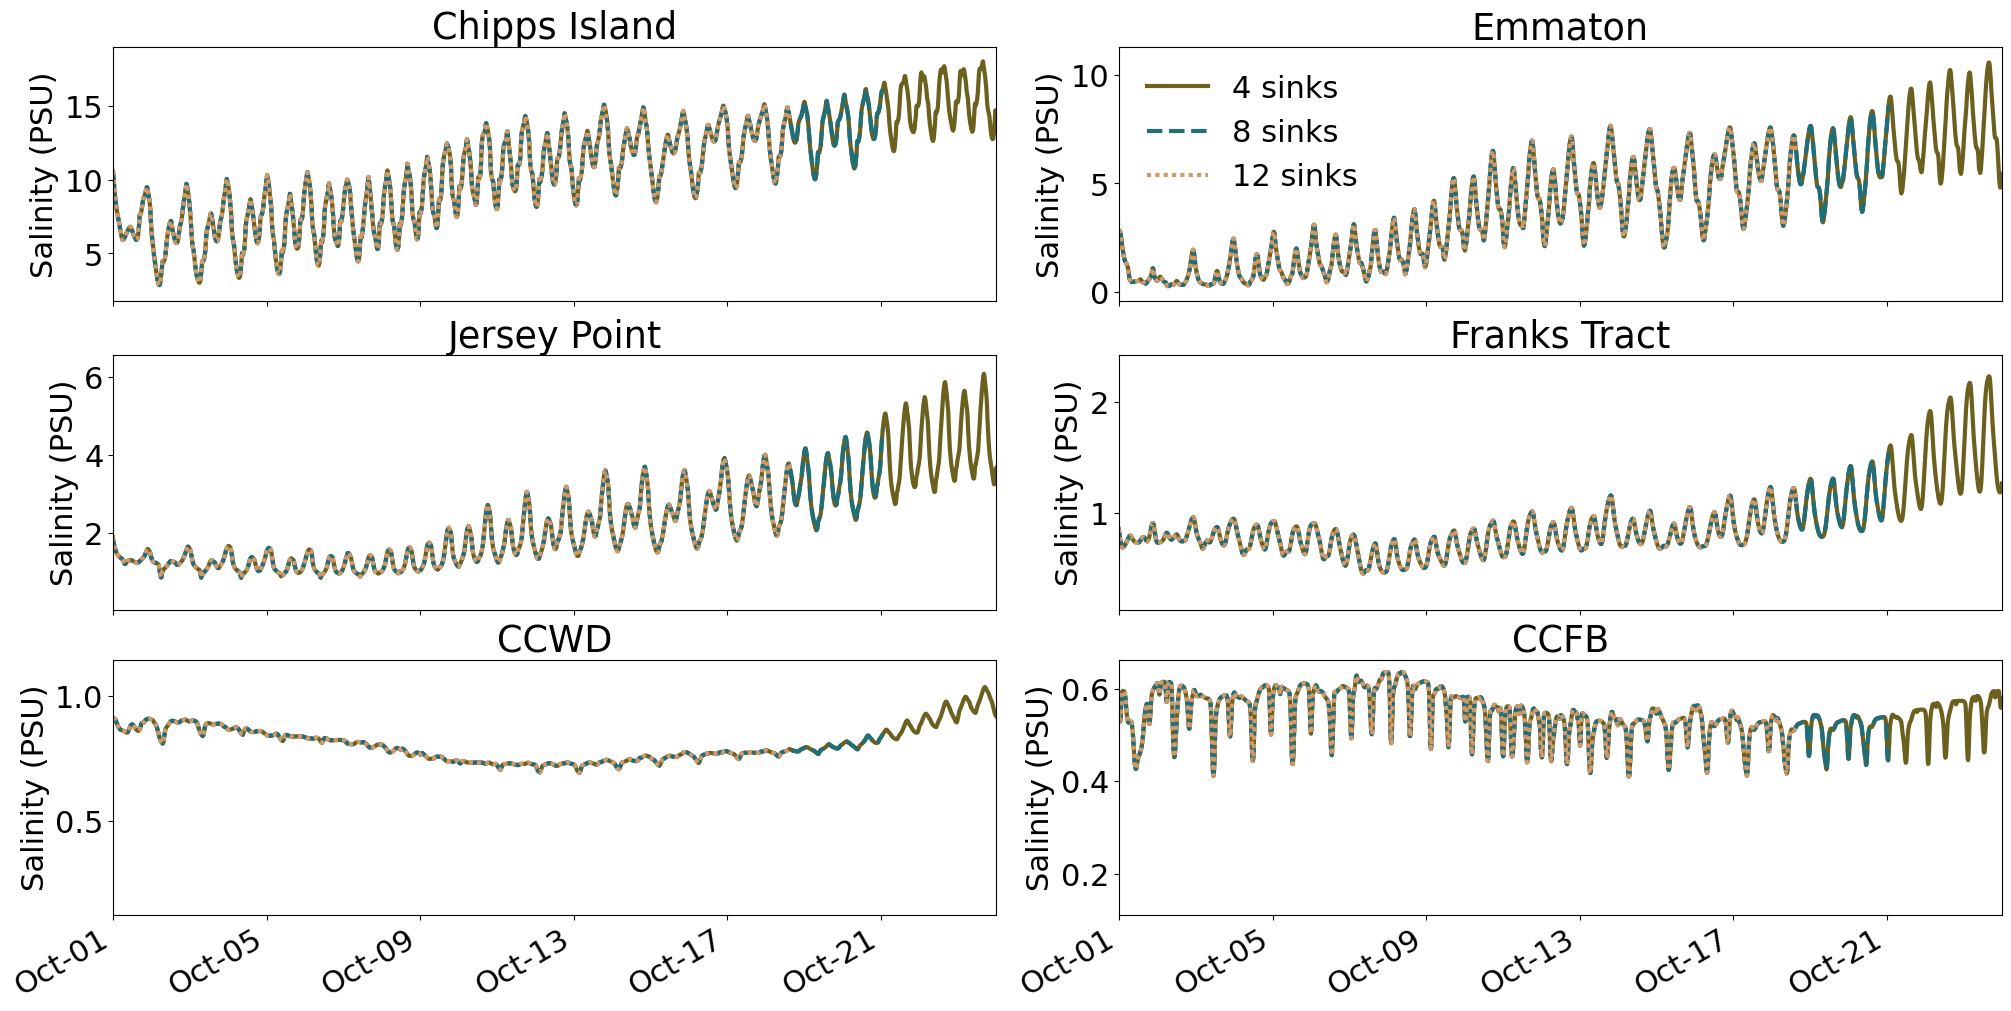

In [7]:
#station_indices=[226,22,12,168,6,203] 
#from Lily:
station_indices=[23,9,22,203,105,60]
fig, ax = plt.subplots(3,2,figsize=(20,10),sharex=True,layout='constrained',label='compliance')
mpl.rcParams.update({'font.size': 22})
# ax.grid(alpha=0.5)
for idx in station_indices:
    if idx == 23:
        s=(0,0)
        tstring='Chipps Island'
        #ax[s].hlines(y=1.3775, xmin=pd.to_datetime("2019-2-1"), xmax=pd.to_datetime("2019-6-1"),color='k',linestyle='--',label='compliance')
        #ax[s].hlines(y=1.3775, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-6-1"),color='k',linestyle='--',label='compliance')
    if idx == 9:
        s=(0,1)
        tstring='Emmaton'
        #ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2019-4-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
        #ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
    if idx == 22:
        s=(1,0)
        tstring='Jersey Point'
        #ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2019-4-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
        #ax[s].hlines(y=0.5055, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-8-15"),color='k',linestyle='--',label='compliance')
    if idx == 203:
        s=(1,1)
        tstring='Franks Tract'
    if idx == 105:
        s=(2,0)
        tstring='CCWD'
        #ax[s].hlines(y=0.3255, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--',label='compliance')
    if idx == 60:
        s=(2,1)
        tstring='CCFB'
        #ax[s].hlines(y=0.3387, xmin=pd.to_datetime("2018-10-1"), xmax=pd.to_datetime("2019-10-1"),color='k',linestyle='--',label='compliance')
    
    print(s)
    values1 = run13_r[str(idx)]
    values2 = run14_r[str(idx)]
    values3 = run15_r[str(idx)]

    #calculate the percent difference using the period when pumping occured
    dif=(values1.loc[pd.to_datetime("2018-10-3"):pd.to_datetime("2018-10-19")]-
            values3.loc[pd.to_datetime("2018-10-3"):pd.to_datetime("2018-10-19")])
    print('Max diff = '+str(np.max(dif))+ ' PSU')
    print('Mean diff = '+str(np.mean(dif))+' PSU')

    perdif=dif/(0.5*(values1.loc[pd.to_datetime("2018-10-3"):pd.to_datetime("2018-10-19")]+
            values3.loc[pd.to_datetime("2018-10-3"):pd.to_datetime("2018-10-19")]))
    print('Max per diff = '+str(100*np.max(perdif))+ ' %')
    print('Mean per diff = '+str(100*np.mean(perdif))+' %')
          
    ax[s].plot(values1, label = '4 sinks', linewidth=3, alpha =1, color=cmocean.cm.tarn(1/6))
    ax[s].plot(values2, label = '8 sinks', linewidth=3, alpha =1,linestyle='--', color=cmocean.cm.tarn(10/12))
    ax[s].plot(values3, label = '12 sinks', linewidth=3, alpha =1,linestyle=(0,(1,1)), color=cmocean.cm.tarn(2/6))
    #ax[s].set_title(stations[idx-1]) #this list is zero indexed
    ax[s].set_title(tstring)
    #ax[s].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2019-9-30"))
    ax[s].set_xlim(pd.to_datetime("2018-10-1"),pd.to_datetime("2018-10-19"))
    ax[s].set_ylabel('Salinity (PSU)')
    # Rotates and right-aligns the x labels so they don't crowd each other.

    
#ax.plot(data1.time,np.ones_like(values1)*std,linewidth=2, alpha =0.7,linestyle='--',color='k',label='Compliance')

#leg = ax.legend()
#print(ax)
#ax.set_xlim(data1.time.iloc[52000], data3.time.iloc[-1]) #July 1 to end
# ax.grid(which='major', color='b', linestyle='-')
#ax.set_title("Salinity from baroclinic run")
#ax[0,1].xaxis.set_major_formatter(mdates.DateFormatter('%b-%d-%Y'))
ax[0,1].legend(frameon=False)
ax[2,0].xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax[2,0].xaxis.get_major_locator()))
ax[2,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%b'))
    # Rotates and right-aligns the x labels so they don't crowd each other.
for label in ax[2,0].get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')
ax[2,1].xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax[2,1].xaxis.get_major_locator()))
ax[2,1].xaxis.set_major_formatter(mdates.DateFormatter('%b-%d'))
    # Rotates and right-aligns the x labels so they don't crowd each other.
for label in ax[2,1].get_xticklabels(which='major'):
    label.set(rotation=30, horizontalalignment='right')

plt.show()
#fig.savefig('six_stations_timeseries_legend_2_endfeb.png')

# Double check that the source sink files are correct

In [34]:
# timeseries paths
ts4='/global/scratch/users/jennaisrael/run_schism/run_test4sinks/vsink.th'
ts8='/global/scratch/users/jennaisrael/run_schism/run_test8sinks/vsink.th'
ts12='/global/scratch/users/jennaisrael/run_schism/run_test12sinks/vsink.th'
list4='/global/scratch/users/jennaisrael/run_schism/run_test4sinks/source_sink.in'
list8='/global/scratch/users/jennaisrael/run_schism/run_test8sinks/source_sink.in'
list12='/global/scratch/users/jennaisrael/run_schism/run_test12sinks/source_sink.in'

In [35]:
# use only sink columns
ss4=pd.read_csv(list4,sep='\s+',header=None)
columns4=np.append(['time'],(ss4[ss4[2].str.contains( "sink" )==True][2]).values)
print(len(columns4))
ss8=pd.read_csv(list8,sep='\s+',header=None)
columns8=np.append(['time'],(ss8[ss8[2].str.contains( "sink" )==True][2]).values)
print(len(columns8))
ss12=pd.read_csv(list12,sep='\s+',header=None)
columns12=np.append(['time'],(ss12[ss12[2].str.contains( "sink" )==True][2]).values)
print(len(columns12))

336
340
344


In [32]:
df4=pd.read_csv(ts4, sep='\s+', names=columns4,dtype=np.float32)
timedelta = [pd.Timedelta(i, unit = 's') for i in df4.time]
timestamp = [pd.to_datetime("08-14-2018 00:00:00") + i for i in timedelta]  
df4['time'] = timestamp
df4.set_index("time",inplace=True)
df4

,delta_sink_1,delta_sink_3,delta_sink_4,delta_sink_5,delta_sink_6,delta_sink_7,delta_sink_8,delta_sink_9,delta_sink_10,delta_sink_11,...,suisun_sink_444,suisun_sink_445,suisun_sink_463,suisun_sink_464,suisun_sink_465,suisun_sink_466,dcp_sink_3,dcp_sink_4,dcp_sink_9,dcp_sink_10
time,,,,,,,,,,,,,,,,,,,,,
2018-08-14,-0.28,-0.18,-3.96,-0.21,-0.09,-0.10,-0.10,-0.08,-0.11,-0.12,...,-0.17,-0.21,-0.12,-0.15,-0.12,-0.12,-55.262161,-55.262161,-55.262161,-55.262161
2018-08-15,-0.29,-0.19,-4.12,-0.22,-0.09,-0.10,-0.11,-0.08,-0.11,-0.12,...,-0.17,-0.21,-0.12,-0.16,-0.12,-0.12,-55.262161,-55.262161,-55.262161,-55.262161
2018-08-16,-0.32,-0.21,-4.65,-0.25,-0.11,-0.11,-0.12,-0.09,-0.12,-0.14,...,-0.19,-0.24,-0.12,-0.16,-0.12,-0.12,-55.262161,-55.262161,-55.262161,-55.262161
2018-08-17,-0.35,-0.23,-5.04,-0.27,-0.11,-0.12,-0.12,-0.10,-0.13,-0.15,...,-0.21,-0.27,-0.13,-0.17,-0.13,-0.13,-55.262161,-55.262161,-55.262161,-55.262161
2018-08-18,-0.36,-0.24,-5.30,-0.28,-0.12,-0.13,-0.13,-0.11,-0.14,-0.15,...,-0.20,-0.26,-0.13,-0.17,-0.13,-0.13,-55.262161,-55.262161,-55.262161,-55.262161
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-09-26,-0.03,-0.01,-0.00,-0.02,-0.01,-0.06,-0.05,-0.04,-0.05,-0.05,...,-0.22,-0.31,-0.12,-0.15,-0.12,-0.12,NaN,NaN,NaN,NaN
2023-09-27,-0.04,-0.02,-0.00,-0.02,-0.01,-0.06,-0.05,-0.04,-0.05,-0.06,...,-0.22,-0.31,-0.12,-0.15,-0.12,-0.12,NaN,NaN,NaN,NaN
2023-09-28,-0.04,-0.02,-0.00,-0.02,-0.01,-0.06,-0.05,-0.03,-0.04,-0.04,...,-0.22,-0.31,-0.12,-0.15,-0.12,-0.12,NaN,NaN,NaN,NaN


In [36]:
df8=pd.read_csv(ts8, sep='\s+', names=columns8,dtype=np.float32)
timedelta = [pd.Timedelta(i, unit = 's') for i in df8.time]
timestamp = [pd.to_datetime("08-14-2018 00:00:00") + i for i in timedelta]  
df8['time'] = timestamp
df8.set_index("time",inplace=True)
df8

,delta_sink_1,delta_sink_3,delta_sink_4,delta_sink_5,delta_sink_6,delta_sink_7,delta_sink_8,delta_sink_9,delta_sink_10,delta_sink_11,...,suisun_sink_465,suisun_sink_466,dcp_sink_3,dcp_sink_4,dcp_sink_5,dcp_sink_6,dcp_sink_7,dcp_sink_8,dcp_sink_9,dcp_sink_10
time,,,,,,,,,,,,,,,,,,,,,
2018-08-14,-0.28,-0.18,-3.96,-0.21,-0.09,-0.10,-0.10,-0.08,-0.11,-0.12,...,-0.12,-0.12,-27.631081,-27.631081,-27.631081,-27.631081,-27.631081,-27.631081,-27.631081,-27.631081
2018-08-15,-0.29,-0.19,-4.12,-0.22,-0.09,-0.10,-0.11,-0.08,-0.11,-0.12,...,-0.12,-0.12,-27.631081,-27.631081,-27.631081,-27.631081,-27.631081,-27.631081,-27.631081,-27.631081
2018-08-16,-0.32,-0.21,-4.65,-0.25,-0.11,-0.11,-0.12,-0.09,-0.12,-0.14,...,-0.12,-0.12,-27.631081,-27.631081,-27.631081,-27.631081,-27.631081,-27.631081,-27.631081,-27.631081
2018-08-17,-0.35,-0.23,-5.04,-0.27,-0.11,-0.12,-0.12,-0.10,-0.13,-0.15,...,-0.13,-0.13,-27.631081,-27.631081,-27.631081,-27.631081,-27.631081,-27.631081,-27.631081,-27.631081
2018-08-18,-0.36,-0.24,-5.30,-0.28,-0.12,-0.13,-0.13,-0.11,-0.14,-0.15,...,-0.13,-0.13,-27.631081,-27.631081,-27.631081,-27.631081,-27.631081,-27.631081,-27.631081,-27.631081
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-09-26,-0.03,-0.01,-0.00,-0.02,-0.01,-0.06,-0.05,-0.04,-0.05,-0.05,...,-0.12,-0.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09-27,-0.04,-0.02,-0.00,-0.02,-0.01,-0.06,-0.05,-0.04,-0.05,-0.06,...,-0.12,-0.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09-28,-0.04,-0.02,-0.00,-0.02,-0.01,-0.06,-0.05,-0.03,-0.04,-0.04,...,-0.12,-0.12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [37]:
df12=pd.read_csv(ts12, sep='\s+', names=columns12,dtype=np.float32)
timedelta = [pd.Timedelta(i, unit = 's') for i in df12.time]
timestamp = [pd.to_datetime("08-14-2018 00:00:00") + i for i in timedelta]  
df12['time'] = timestamp
df12.set_index("time",inplace=True)
df12

,delta_sink_1,delta_sink_3,delta_sink_4,delta_sink_5,delta_sink_6,delta_sink_7,delta_sink_8,delta_sink_9,delta_sink_10,delta_sink_11,...,dcp_sink_3,dcp_sink_4,dcp_sink_5,dcp_sink_6,dcp_sink_7,dcp_sink_8,dcp_sink_9,dcp_sink_10,dcp_sink_11,dcp_sink_12
time,,,,,,,,,,,,,,,,,,,,,
2018-08-14,-0.28,-0.18,-3.96,-0.21,-0.09,-0.10,-0.10,-0.08,-0.11,-0.12,...,-18.420721,-18.420721,-18.420721,-18.420721,-18.420721,-18.420721,-18.420721,-18.420721,-18.420721,-18.420721
2018-08-15,-0.29,-0.19,-4.12,-0.22,-0.09,-0.10,-0.11,-0.08,-0.11,-0.12,...,-18.420721,-18.420721,-18.420721,-18.420721,-18.420721,-18.420721,-18.420721,-18.420721,-18.420721,-18.420721
2018-08-16,-0.32,-0.21,-4.65,-0.25,-0.11,-0.11,-0.12,-0.09,-0.12,-0.14,...,-18.420721,-18.420721,-18.420721,-18.420721,-18.420721,-18.420721,-18.420721,-18.420721,-18.420721,-18.420721
2018-08-17,-0.35,-0.23,-5.04,-0.27,-0.11,-0.12,-0.12,-0.10,-0.13,-0.15,...,-18.420721,-18.420721,-18.420721,-18.420721,-18.420721,-18.420721,-18.420721,-18.420721,-18.420721,-18.420721
2018-08-18,-0.36,-0.24,-5.30,-0.28,-0.12,-0.13,-0.13,-0.11,-0.14,-0.15,...,-18.420721,-18.420721,-18.420721,-18.420721,-18.420721,-18.420721,-18.420721,-18.420721,-18.420721,-18.420721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-09-26,-0.03,-0.01,-0.00,-0.02,-0.01,-0.06,-0.05,-0.04,-0.05,-0.05,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09-27,-0.04,-0.02,-0.00,-0.02,-0.01,-0.06,-0.05,-0.04,-0.05,-0.06,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-09-28,-0.04,-0.02,-0.00,-0.02,-0.01,-0.06,-0.05,-0.03,-0.04,-0.04,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [29]:
df4['dcp_sink_3']

time
2018-08-14   -0.12
2018-08-15   -0.12
2018-08-16   -0.12
2018-08-17   -0.13
2018-08-18   -0.13
              ... 
2023-09-26   -0.12
2023-09-27   -0.12
2023-09-28   -0.12
2023-09-29   -0.12
2023-09-30   -0.12
Name: dcp_sink_3, Length: 1874, dtype: float32

In [ ]:
# what was the swap for the warm up period